In [1]:
#!/usr/bin/env python
"""
Stage 3: BPR (Bayesian Personalized Ranking) Experiment
Exploring algorithms specifically designed for ranking with implicit feedback

Motivation from Stage 2:
- SVD/ALS showed good rating prediction (RMSE) but poor ranking metrics
- Linear models have limited expressiveness 
- Need algorithms designed specifically for ranking tasks
- Matrix factorization assumptions may be too restrictive

BPR addresses these issues by:
- Optimizing directly for ranking (AUC) rather than rating prediction
- Using pairwise learning approach 
- Designed specifically for implicit feedback scenarios
"""

import warnings
warnings.filterwarnings("ignore")
import logging
logging.basicConfig(level=logging.ERROR)

import os
import sys
import numpy as np
import pandas as pd
import cornac
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Add path for benchmark_utils
current_path = os.path.join(os.getcwd(), "examples", "06_benchmarks")
sys.path.append(current_path)

try:
    from benchmark_utils import *
except ImportError:
    print("Warning: benchmark_utils not found, defining functions locally")

from recommenders.datasets import movielens
from recommenders.datasets.python_splitters import python_stratified_split
from recommenders.evaluation.python_evaluation import (
    map_at_k, ndcg_at_k, precision_at_k, recall_at_k
)
from recommenders.utils.constants import (
    DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL, 
    DEFAULT_TIMESTAMP_COL, DEFAULT_PREDICTION_COL, SEED
)
from recommenders.utils.timer import Timer
from recommenders.models.cornac.cornac_utils import predict_ranking


In [2]:

# Set random seed
np.random.seed(SEED)

# Configuration
DATA_SIZE = "100k" 
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"=== Stage 3: BPR (Bayesian Personalized Ranking) Experiment ===")
print(f"Start time: {datetime.now()}")
print("\nContext from previous stages:")
print("- Stage 1 (SAR): Good ranking metrics but no rating prediction")
print("- Stage 2 (SVD/ALS): Good rating prediction but poor ranking")
print("- Stage 3 Goal: Optimize directly for ranking with BPR")

# Load data
print(f"\nLoading MovieLens {DATA_SIZE} dataset...")
df = movielens.load_pandas_df(
    size=DATA_SIZE,
    header=[DEFAULT_USER_COL, DEFAULT_ITEM_COL, DEFAULT_RATING_COL, DEFAULT_TIMESTAMP_COL]
)
print(f"Dataset shape: {df.shape}")

# Data split
print("\nSplitting data (75/25)...")
df_train, df_test = python_stratified_split(
    df, 
    ratio=0.75,
    min_rating=1,
    filter_by="item",
    col_user=DEFAULT_USER_COL,
    col_item=DEFAULT_ITEM_COL
)
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")

# Convert to implicit feedback for BPR
print("\nConverting to implicit feedback (rating >= 4 → positive)...")
df_train_implicit = df_train[df_train[DEFAULT_RATING_COL] >= 4].copy()
df_test_implicit = df_test[df_test[DEFAULT_RATING_COL] >= 4].copy()
print(f"Implicit train shape: {df_train_implicit.shape}")
print(f"Implicit test shape: {df_test_implicit.shape}")


=== Stage 3: BPR (Bayesian Personalized Ranking) Experiment ===
Start time: 2025-06-05 09:05:20.433590

Context from previous stages:
- Stage 1 (SAR): Good ranking metrics but no rating prediction
- Stage 2 (SVD/ALS): Good rating prediction but poor ranking
- Stage 3 Goal: Optimize directly for ranking with BPR

Loading MovieLens 100k dataset...


100%|██████████| 4.81k/4.81k [00:01<00:00, 2.81kKB/s]


Dataset shape: (100000, 4)

Splitting data (75/25)...
Train shape: (75066, 4), Test shape: (24934, 4)

Converting to implicit feedback (rating >= 4 → positive)...
Implicit train shape: (41546, 4)
Implicit test shape: (13829, 4)


In [3]:

# ========== BPR Experiment ==========
print("\n=== BPR Experiment ===")
print("Key advantages of BPR:")
print("- Optimizes AUC directly (pairwise ranking)")
print("- Designed for implicit feedback")
print("- Assumes: observed > unobserved items")

# BPR parameters
bpr_params = {
    "k": 50,  # Number of latent factors
    "max_iter": 100,
    "learning_rate": 0.01,
    "lambda_reg": 0.001,
    "seed": SEED,
    "verbose": True
}

# Prepare data for Cornac
print("\nPreparing data for BPR...")
train_cornac = cornac.data.Dataset.from_uir(
    df_train_implicit.drop(DEFAULT_TIMESTAMP_COL, axis=1).itertuples(index=False), 
    seed=SEED
)

# Train BPR
print(f"\nTraining BPR model with {bpr_params['k']} factors...")
bpr_model = cornac.models.BPR(**bpr_params)
with Timer() as t:
    bpr_model.fit(train_cornac)
bpr_train_time = t.interval
print(f"Training completed in {bpr_train_time:.4f} seconds")

# Make predictions
print("\nMaking ranking predictions...")
k = 10
with Timer() as t:
    top_k_scores = predict_ranking(
        bpr_model,
        df_train_implicit,
        usercol=DEFAULT_USER_COL,
        itemcol=DEFAULT_ITEM_COL,
        predcol=DEFAULT_PREDICTION_COL,
        remove_seen=True
    )
bpr_predict_time = t.interval
print(f"Prediction completed in {bpr_predict_time:.4f} seconds")



=== BPR Experiment ===
Key advantages of BPR:
- Optimizes AUC directly (pairwise ranking)
- Designed for implicit feedback
- Assumes: observed > unobserved items

Preparing data for BPR...

Training BPR model with 50 factors...


  0%|          | 0/100 [00:00<?, ?it/s]

Optimization finished!
Training completed in 0.6090 seconds

Making ranking predictions...
Prediction completed in 1.2748 seconds


In [4]:

# Evaluate
print("\nEvaluating BPR performance...")
bpr_results = {
    "Model": "BPR",
    "Data_Size": DATA_SIZE,
    "Train_Time": bpr_train_time,
    "Predict_Time": bpr_predict_time,
    "K": k,
    "Factors": bpr_params["k"],
    "MAP": map_at_k(df_test_implicit, top_k_scores, k=k, **{"col_user": DEFAULT_USER_COL, "col_item": DEFAULT_ITEM_COL, "col_rating": DEFAULT_RATING_COL, "col_prediction": DEFAULT_PREDICTION_COL}),
    "NDCG@K": ndcg_at_k(df_test_implicit, top_k_scores, k=k, **{"col_user": DEFAULT_USER_COL, "col_item": DEFAULT_ITEM_COL, "col_rating": DEFAULT_RATING_COL, "col_prediction": DEFAULT_PREDICTION_COL}),
    "Precision@K": precision_at_k(df_test_implicit, top_k_scores, k=k, **{"col_user": DEFAULT_USER_COL, "col_item": DEFAULT_ITEM_COL, "col_rating": DEFAULT_RATING_COL, "col_prediction": DEFAULT_PREDICTION_COL}),
    "Recall@K": recall_at_k(df_test_implicit, top_k_scores, k=k, **{"col_user": DEFAULT_USER_COL, "col_item": DEFAULT_ITEM_COL, "col_rating": DEFAULT_RATING_COL, "col_prediction": DEFAULT_PREDICTION_COL})
}

# Analyze recommendation diversity
print("\nAnalyzing recommendation patterns...")
unique_items = top_k_scores[DEFAULT_ITEM_COL].nunique()
total_items = df_train[DEFAULT_ITEM_COL].nunique()
catalog_coverage = unique_items / total_items

bpr_results["Unique_Items_Recommended"] = unique_items
bpr_results["Catalog_Coverage"] = catalog_coverage

# Item popularity analysis
item_popularity = df_train_implicit.groupby(DEFAULT_ITEM_COL).size().reset_index(name='popularity')
top_20_popular = item_popularity.nlargest(20, 'popularity')[DEFAULT_ITEM_COL].values
rec_items = top_k_scores[DEFAULT_ITEM_COL].value_counts().head(20)
popular_in_recs = sum([item in top_20_popular for item in rec_items.index])
bpr_results["Popular_Items_in_Top20_Recs"] = popular_in_recs



Evaluating BPR performance...

Analyzing recommendation patterns...


In [5]:

# ========== Comparative Analysis ==========
print("\n=== Comparative Analysis with Previous Stages ===")

# Load previous results
stage1_file = os.path.join(RESULTS_DIR, "stage1_sar_results.csv")
stage2_file = os.path.join(RESULTS_DIR, "stage2_svd_als_results.csv")

comparison_data = []

if os.path.exists(stage1_file):
    sar_results = pd.read_csv(stage1_file).iloc[0]
    comparison_data.append({
        "Stage": "1-SAR",
        "Algorithm": "SAR",
        "NDCG@K": sar_results['NDCG@K'],
        "Precision@K": sar_results['Precision@K'],
        "Recall@K": sar_results['Recall@K'],
        "Catalog_Coverage": sar_results['Catalog_Coverage']
    })

if os.path.exists(stage2_file):
    svd_results = pd.read_csv(stage2_file)
    svd_row = svd_results[svd_results['Model'] == 'SVD'].iloc[0]
    comparison_data.append({
        "Stage": "2-SVD",
        "Algorithm": "SVD",
        "NDCG@K": svd_row['NDCG@K'],
        "Precision@K": svd_row['Precision@K'],
        "Recall@K": svd_row['Recall@K'],
        "RMSE": svd_row['RMSE']
    })

comparison_data.append({
    "Stage": "3-BPR",
    "Algorithm": "BPR",
    "NDCG@K": bpr_results['NDCG@K'],
    "Precision@K": bpr_results['Precision@K'],
    "Recall@K": bpr_results['Recall@K'],
    "Catalog_Coverage": bpr_results['Catalog_Coverage']
})

comparison_df = pd.DataFrame(comparison_data)
print("\nPerformance Comparison:")
print(comparison_df.to_string(index=False))



=== Comparative Analysis with Previous Stages ===

Performance Comparison:
Stage Algorithm   NDCG@K  Precision@K  Recall@K  Catalog_Coverage     RMSE
1-SAR       SAR 0.312120     0.280331  0.110633          0.319482      NaN
2-SVD       SVD 0.094445     0.089077  0.030094               NaN 0.942506
3-BPR       BPR 0.266640     0.218730  0.177607          0.838288      NaN



Results saved to results/stage3_bpr_results.csv
Visualization saved to results/stage3_comparison.png


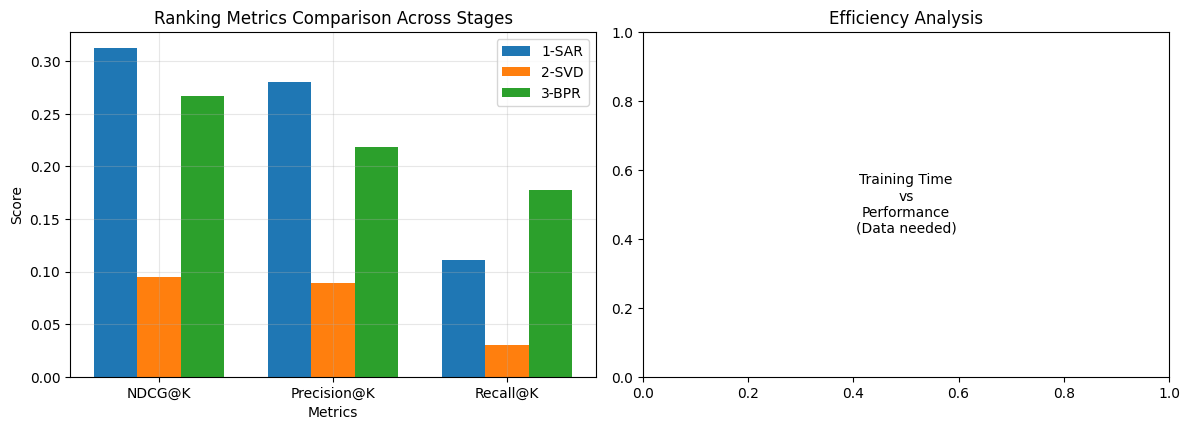

In [6]:

# Create visualization
plt.figure(figsize=(12, 8))

# Subplot 1: Ranking Metrics Comparison
plt.subplot(2, 2, 1)
metrics = ['NDCG@K', 'Precision@K', 'Recall@K']
stages = ['1-SAR', '2-SVD', '3-BPR']
x = np.arange(len(metrics))
width = 0.25

for i, stage in enumerate(stages):
    if stage in comparison_df['Stage'].values:
        row = comparison_df[comparison_df['Stage'] == stage].iloc[0]
        values = [row.get(m, 0) for m in metrics]
        plt.bar(x + i*width, values, width, label=stage)

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Ranking Metrics Comparison Across Stages')
plt.xticks(x + width, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Training Time vs Performance
plt.subplot(2, 2, 2)
if len(comparison_data) > 0:
    # This would need actual timing data
    plt.text(0.5, 0.5, 'Training Time\nvs\nPerformance\n(Data needed)', 
             ha='center', va='center', transform=plt.gca().transAxes)
plt.title('Efficiency Analysis')

# Save results
results_df = pd.DataFrame([bpr_results])
results_file = os.path.join(RESULTS_DIR, "stage3_bpr_results.csv")
results_df.to_csv(results_file, index=False)
print(f"\nResults saved to {results_file}")

# Save visualization
viz_file = os.path.join(RESULTS_DIR, "stage3_comparison.png")
plt.tight_layout()
plt.savefig(viz_file, dpi=150, bbox_inches='tight')
print(f"Visualization saved to {viz_file}")


In [7]:

# ========== Key Findings ==========
print("\n=== Stage 3 Key Findings ===")
print(f"✅ BPR achieves NDCG@K: {bpr_results['NDCG@K']:.4f}")
print(f"✅ Precision@K: {bpr_results['Precision@K']:.4f}")
print(f"✅ Recall@K: {bpr_results['Recall@K']:.4f}")
print(f"✅ Catalog Coverage: {bpr_results['Catalog_Coverage']:.2%}")
print(f"✅ Training time: {bpr_train_time:.2f}s (efficient)")


print("\nImprovements over Stage 2:")
if 'svd_row' in locals():
    print(f"- NDCG improved from {svd_row['NDCG@K']:.4f} (SVD) to {bpr_results['NDCG@K']:.4f} (BPR)")
    print(f"- Precision improved from {svd_row['Precision@K']:.4f} to {bpr_results['Precision@K']:.4f}")
    print("- Optimized directly for ranking instead of rating prediction")

print("\nRemaining Challenges:")
print("❌ Still based on matrix factorization (linear interactions)")
print("❌ Cannot capture complex non-linear patterns")
print("❌ Limited expressiveness compared to deep learning")
print("❌ Popularity bias still present")

print("\n=== Next Steps (Stage 4+) ===")
print("Deep Learning Approaches:")
print("1. NCF (Neural Collaborative Filtering) - Non-linear interactions")
print("2. Variational Autoencoders (BiVAE) - Better generalization")
print("3. Graph Neural Networks (LightGCN) - Leverage graph structure")
print("\nThese methods should address:")
print("- Non-linear user-item interactions")
print("- Better representation learning")
print("- Improved generalization")

print(f"\nEnd time: {datetime.now()}")
print("\n" + "="*60)
print("Stage 3 completed. BPR shows ranking-focused optimization works!")
print("Ready for deep learning methods in Stage 4...")
print("="*60)


=== Stage 3 Key Findings ===
✅ BPR achieves NDCG@K: 0.2666
✅ Precision@K: 0.2187
✅ Recall@K: 0.1776
✅ Catalog Coverage: 83.83%
✅ Training time: 0.61s (efficient)

Improvements over Stage 2:
- NDCG improved from 0.0944 (SVD) to 0.2666 (BPR)
- Precision improved from 0.0891 to 0.2187
- Optimized directly for ranking instead of rating prediction

Remaining Challenges:
❌ Still based on matrix factorization (linear interactions)
❌ Cannot capture complex non-linear patterns
❌ Limited expressiveness compared to deep learning
❌ Popularity bias still present

=== Next Steps (Stage 4+) ===
Deep Learning Approaches:
1. NCF (Neural Collaborative Filtering) - Non-linear interactions
2. Variational Autoencoders (BiVAE) - Better generalization
3. Graph Neural Networks (LightGCN) - Leverage graph structure

These methods should address:
- Non-linear user-item interactions
- Better representation learning
- Improved generalization

End time: 2025-06-05 09:05:33.550516

Stage 3 completed. BPR shows ran